# Stage 4 — VLM Event Extraction (windows.json + video -> events.json)

Model: **Qwen2.5-VL-7B-Instruct**, loaded in 4-bit (fits comfortably on a single Kaggle T4, ~6-7GB VRAM). Pretrained, no fine-tuning for the MVP.

**Input:** `windows.json` (Stage 2 output) + the original video file it was built from.

**Output:** `events.json` -- one record per confirmed event, only for events the model actually validated against real track IDs in that window.

**The core idea:** for each window, sample a few frames and hand the model the `candidate_events` Stage 2 already derived by rule. You are not asking "what's happening?" -- you are asking it to confirm, reject, or correct evidence you already have. This is what stops it hallucinating identities, and it's why Stage 2 exists before this stage at all.

Single video first, matching how Stage 1b/2 were built.


## 0. Install

`transformers` must be recent enough to include `Qwen2_5_VLForConditionalGeneration` -- the base pip version often isn't. `qwen-vl-utils` handles turning frames into the format the processor expects; without it you'll be reimplementing its resize/patch logic by hand.

In [14]:
!pip install -q -U transformers accelerate bitsandbytes qwen-vl-utils opencv-python-headless


In [15]:
import os, json, re
from pathlib import Path

import cv2
import torch
import numpy as np
from PIL import Image
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor, BitsAndBytesConfig
from qwen_vl_utils import process_vision_info

print("Setup ready. CUDA available:", torch.cuda.is_available())


Setup ready. CUDA available: True


## 1. Config

Point these at Stage 2's `windows.json`, the matching video file, and pick which `video_id` to run (single video first -- switch to a loop over all video_ids once this is confirmed working, the same way Stage 1b started single-video before batch).

In [16]:
WINDOWS_JSON = "/kaggle/input/datasets/aryanakhare/needed-video/windows.json"     # Stage 2 output
VIDEO_PATH   = "/kaggle/input/datasets/aryanakhare/needed-video/Burglary001_x264A.mp4"  # <-- match this to the video windows.json was built from
OUTPUT_PATH  = "/kaggle/working/events.json"

FRAMES_PER_WINDOW = 5   # 3-6 per the architecture doc; more frames = slower, more context
MAX_RETRIES        = 2    # retries on malformed JSON / hallucinated track_id before dropping the window

MODEL_ID = "Qwen/Qwen2.5-VL-7B-Instruct"

EVENT_TYPES = ["enter", "exit", "walk", "run", "stop", "loiter", "carry", "place",
               "pickup", "stationary", "approach", "interact_vehicle"]

assert os.path.exists(WINDOWS_JSON), f"Run Stage 2 first -- missing {WINDOWS_JSON}"
assert os.path.exists(VIDEO_PATH), f"Set VIDEO_PATH to the real clip: {VIDEO_PATH}"
print("Config OK.")


Config OK.


## 2. Load Qwen2.5-VL in 4-bit

This is the step that actually needs a GPU. `device_map="auto"` places layers on whatever's available; on a single T4 that's just "all on the one GPU".

In [17]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_quant_type="nf4",
)

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
)
processor = AutoProcessor.from_pretrained(MODEL_ID)

print(f"Loaded {MODEL_ID} in 4-bit.")
print(f"GPU memory allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB" 
      if torch.cuda.is_available() else "Running on CPU -- will be slow.")


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

Loaded Qwen/Qwen2.5-VL-7B-Instruct in 4-bit.
GPU memory allocated: 3.23 GB


## 3. Load windows.json and pick one video


In [18]:
with open(WINDOWS_JSON) as f:
    all_windows = json.load(f)["windows"]

video_ids = sorted({w["video_id"] for w in all_windows})
print(f"video_ids in windows.json: {video_ids}")

TARGET_VIDEO_ID = video_ids[0]   # <-- change if windows.json has more than one and you want a different one
video_windows = [w for w in all_windows if w["video_id"] == TARGET_VIDEO_ID]
print(f"Running on video_id={TARGET_VIDEO_ID}: {len(video_windows)} windows")


video_ids in windows.json: ['Burglary001_x264A']
Running on video_id=Burglary001_x264A: 10 windows


## 4. Frame extraction

Pulls `FRAMES_PER_WINDOW` evenly-spaced frames from the video between a window's `[start, end]` timestamps.

Extracted 15 frames for window [25.47, 35.47]


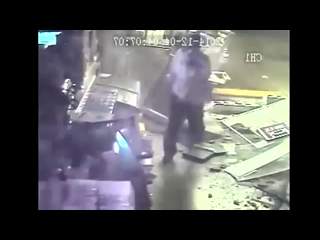

In [19]:
def extract_frames(video_path: str, t_start: float, t_end: float, n_frames: int) -> list:
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    timestamps = np.linspace(t_start, max(t_end, t_start + 0.1), n_frames)
    frames = []
    for t in timestamps:
        frame_idx = min(int(t * fps), total_frames - 1)
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ok, frame_bgr = cap.read()
        if not ok:
            continue
        frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
        frames.append(Image.fromarray(frame_rgb))

    cap.release()
    return frames


# Quick sanity check on the first window
if video_windows:
    _t0, _t1 = video_windows[0]["window"]
    _test_frames = extract_frames(VIDEO_PATH, _t0, _t1, FRAMES_PER_WINDOW)
    print(f"Extracted {len(_test_frames)} frames for window [{_t0}, {_t1}]")
    if _test_frames:
        display(_test_frames[0])


## 5. Prompt construction

Matches the prompt shape from the architecture doc: system message constrains the model to the fixed event vocabulary and JSON-only output; the user message gives the tracked-object summary for the window (from `windows.json`) plus the candidate events Stage 2 already derived, and asks the model to confirm, reject, or correct them -- not invent new subjects.

In [28]:
SYSTEM_PROMPT = (
    "You describe video surveillance events. Reply ONLY with JSON matching the given schema, "
    "no preamble, no markdown fences. "
    "Use subject_track and object_track values from the 'Tracked objects' list below. "
    "If a candidate event is valid, confirm it. If no specific action occurs, create an event "
    "with event_type 'scene_description' and describe what the tracked objects are doing. "
    "Always return at least one descriptive event."
)

SCHEMA_HINT = (
    '{"events": [{"event_type": str, "subject_track": int_or_null, '
    '"object_track": int_or_null, "start": float, "end": float, '
    '"zone": str, "confidence": float, "description": str}]}'
)

def build_user_prompt(window: dict) -> str:
    lines = [f"Tracked objects in window {window['window'][0]}-{window['window'][1]}s:"]
    candidate_events = []
    for t in window["tracks"]:
        desc = f"- {t['class']} #{t['track_id']}: present {t['dwell_sec']}s"
        if t.get("zones"):
            desc += f", zones: {' -> '.join(t['zones'])}"
        if t.get("held_by") is not None:
            desc += f", held by #{t['held_by']}"
        if t.get("released_at") is not None:
            desc += f", released at {t['released_at']}s"
        lines.append(desc)
        for ev in t.get("candidate_events", []):
            candidate_events.append(f"{ev}({t['track_id']})")

    lines.append("")
    lines.append(f"Candidate events from motion rules: [{', '.join(candidate_events)}]")
    lines.append("Describe the actions in these frames. Schema: " + SCHEMA_HINT)
    return "\n".join(lines)

## 6. Model call + the hallucination guard

Every response is checked against two things before it's accepted: (1) valid JSON matching the schema, (2) every `subject_track`/`object_track` the model names actually appears in that window's track list. Fails either check -> retry up to `MAX_RETRIES`, then drop that window's events rather than accept unverified output. This is the guard the architecture doc calls for -- reject and retry on a `subject_track` that wasn't in the window.

In [29]:
import time

def call_qwen(frames: list, user_prompt: str) -> str:
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content":
            [{"type": "image", "image": f} for f in frames]
            + [{"type": "text", "text": user_prompt}]},
    ]
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, video_inputs = process_vision_info(messages)
    inputs = processor(text=[text], images=image_inputs, videos=video_inputs,
                        padding=True, return_tensors="pt").to(model.device)

    with torch.no_grad():
        # --- CHANGE max_new_tokens TO 1024 HERE ---
        generated_ids = model.generate(**inputs, max_new_tokens=1024)
        
    generated_ids_trimmed = [out[len(inp):] for inp, out in
                              zip(inputs.input_ids, generated_ids)]
    output_text = processor.batch_decode(generated_ids_trimmed, skip_special_tokens=True,
                                          clean_up_tokenization_spaces=False)[0]
    return output_text


def parse_and_validate(raw_text: str, window: dict) -> list:
    cleaned = re.sub(r"^```(json)?|```$", "", raw_text.strip(), flags=re.MULTILINE).strip()
    parsed = json.loads(cleaned)

    if isinstance(parsed, list):
        parsed = {"events": parsed}

    if "events" not in parsed or not isinstance(parsed["events"], list):
        raise ValueError("Response missing top-level 'events' list")

    known_ids = {t["track_id"] for t in window["tracks"]}
    validated = []
    for ev in parsed["events"]:
        # Removed the strict required fields check to be more permissive
        subj = ev.get("subject_track")
        if subj is not None and subj not in known_ids:
            # Only enforce track IDs if the model actually provided one
            raise ValueError(f"subject_track {subj} not in window (known: {known_ids})")
            
        obj = ev.get("object_track")
        if obj is not None and obj not in known_ids:
            raise ValueError(f"object_track {obj} not in window")
            
        validated.append({
            "event_type": ev.get("event_type", "scene_description"),
            "subject_track": int(subj) if subj is not None else None,
            "object_track": int(obj) if obj is not None else None,
            "start": float(ev.get("start", window["window"][0])),
            "end": float(ev.get("end", window["window"][1])),
            "zone": ev.get("zone"),
            "confidence": float(ev.get("confidence", 0.8)),
            "description": str(ev.get("description", "")),
        })
    return validated


def process_window(window: dict, video_path: str) -> list:
    frames = extract_frames(video_path, window["window"][0], window["window"][1],
                             FRAMES_PER_WINDOW)
    if not frames:
        print(f"  window {window['window']}: no frames extracted, skipping")
        return []

    user_prompt = build_user_prompt(window)
    last_error = None
    for attempt in range(MAX_RETRIES + 1):
        raw = call_qwen(frames, user_prompt)
        try:
            return parse_and_validate(raw, window)
        except (ValueError, json.JSONDecodeError) as e:
            last_error = e
            print(f"  window {window['window']}: attempt {attempt+1} rejected -- {e}")

    print(f"  window {window['window']}: dropped after {MAX_RETRIES+1} attempts "
          f"(last error: {last_error})")
    return []


## 7. Run over the single video's windows


In [30]:
import time
import json
from tqdm.auto import tqdm

run_start = time.time()

for i, window in enumerate(tqdm(video_windows, desc="Extracting events")):
    w_start = time.time()
    print(f"[{i+1}/{len(video_windows)}] window {window['window']} "
          f"({len(window['tracks'])} tracks)")
    
    events = process_window(window, VIDEO_PATH)
    
    # Inject the events directly into the window dictionary
    window["events"] = events
    
    print(f"    window took {time.time() - w_start:.1f}s, found {len(events)} events")

print(f"\nTotal run time: {time.time() - run_start:.1f}s")

# Save the original JSON structure with the new "events" fields included
with open(OUTPUT_PATH, "w") as f:
    json.dump({"windows": video_windows}, f, indent=2)

print(f"Saved complete structure -> {OUTPUT_PATH}")

Extracting events:   0%|          | 0/10 [00:00<?, ?it/s]

[1/10] window [25.47, 35.47] (4 tracks)
    window took 96.3s, found 8 events
[2/10] window [30.47, 40.47] (2 tracks)
    window took 28.0s, found 1 events
[3/10] window [35.47, 45.47] (3 tracks)
    window took 43.5s, found 3 events
[4/10] window [40.47, 50.47] (2 tracks)
    window took 27.0s, found 1 events
[5/10] window [45.47, 55.47] (1 tracks)
    window took 28.9s, found 1 events
[6/10] window [50.47, 60.47] (1 tracks)
    window took 35.8s, found 2 events
[7/10] window [55.47, 65.47] (3 tracks)
    window took 48.9s, found 3 events
[8/10] window [60.47, 70.47] (3 tracks)
    window took 38.2s, found 2 events
[9/10] window [65.47, 75.47] (2 tracks)
    window took 35.8s, found 2 events
[10/10] window [70.47, 80.47] (1 tracks)
    window took 27.3s, found 1 events

Total run time: 409.7s
Saved complete structure -> /kaggle/working/events.json


## 8. Save events.json


In [26]:
with open(OUTPUT_PATH, "w") as f:
    json.dump({"events": all_events}, f, indent=2)

print(f"Saved {len(all_events)} events -> {OUTPUT_PATH}")
for ev in all_events[:5]:
    print(f"  {ev['event_type']:>10} | track {ev['subject_track']} -> "
          f"{ev.get('object_track')} | {ev['start']:.1f}-{ev['end']:.1f}s | "
          f"{ev['description']}")


Saved 19 events -> /kaggle/working/events.json
       enter | track 2 -> None | 2.6-3.8s | Person #2 enters the frame.
        exit | track 2 -> None | 3.8-4.8s | Person #2 exits the frame.
       enter | track 5 -> None | 0.4-1.1s | Person #5 enters the frame.
        exit | track 5 -> None | 1.1-1.6s | Person #5 exits the frame.
       enter | track 6 -> None | 0.2-0.6s | Person #6 enters the frame.


In [1]:
from IPython.display import FileLink

# This will generate a clickable link in your notebook output to download the file
FileLink('/kaggle/working/events.json')

/kaggle/working/events.json

## Notes

- **Single video only, on purpose.** Once this runs clean on one clip, wrap Section 7 in a loop over `video_ids` the same way Stage 1b went from single-video to `process_folder`.
- **The retry/drop behavior in Section 6 is the grounding guarantee**, not an edge case to tune away: a window that never produces valid, non-hallucinated JSON contributes zero events, rather than passing unverified content downstream to Stage 6/7.
- **`confidence` defaults to 0.5** if the model doesn't return one -- don't treat missing confidence as a bug, just a signal that field is weakly supported for that event.
- If generation is slow on a T4, lowering `FRAMES_PER_WINDOW` to 3 is the first knob to try before touching `max_new_tokens`.
